# Multiple Instance Learning

In [17]:
from mil.models import MIL_model, MLP_encoder, MaxAggergation, AttentionAggregation, GatedAttentionAggregation
from mil.training_utils import model_run, set_seed
from mil.evaluation_utils import evaluate_accuracy
from mil.CustomDataloader import CustomLoader
from mil.CellsData import CellsData

from mil import PROJECT_ROOT

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [18]:
# Set to True if you want to use original sparse matrix data, False if you want low dimensional embeddings
use_sparse_data = True


if use_sparse_data:
    INPUT_SIZE = 2000
    BAG_KEY = 'bag'
    NUM_EPOCHS = 30
else:
    INPUT_SIZE = 30
    BAG_KEY = 'bag_embed'
    NUM_EPOCHS = 30

In [19]:
train_set = CellsData(split="train")
val_set = CellsData(split="val")
test_set = CellsData(split="test")

n_bags = sum([len(el) for el in (train_set, val_set, test_set)])
print(f"The entire datatset contains {n_bags} bags.")

train_loader = CustomLoader(train_set, batchsize=20)
validation_loader = CustomLoader(val_set, batchsize=20)
test_loader = CustomLoader(test_set, batchsize=20)

The entire datatset contains 146 bags.


In [20]:
def run_evaluation(encoder: nn.Module, aggregator: nn.Module, lr: float, decay: float, plot_title: str, path_prefix: str):
    model = MIL_model(instance_encoder=encoder, bag_aggregator=aggregator)


    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=decay)

    fig, ax = plt.subplots()


    train_loss, valid_loss, best_epoch = model_run(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        save_path_prefix=path_prefix,
        ax=ax,
        plot_title=plot_title,
        sparse=use_sparse_data,
    )

    path = path_prefix + f"{best_epoch}.torch"
    model = torch.load(path, weights_only=False)
    evaluate_accuracy(model=model, dataset=test_set, bag_key = BAG_KEY, mode = 'Test')

## Maximum aggregation

Epoch 1/30, Train Loss: 0.3596, Validation Loss: 0.3576
Epoch 2/30, Train Loss: 0.3477, Validation Loss: 0.3562
Epoch 3/30, Train Loss: 0.3413, Validation Loss: 0.3455
Epoch 4/30, Train Loss: 0.3417, Validation Loss: 0.3454
Epoch 5/30, Train Loss: 0.3406, Validation Loss: 0.3492
Epoch 6/30, Train Loss: 0.3344, Validation Loss: 0.3441
Epoch 7/30, Train Loss: 0.3345, Validation Loss: 0.3422
Epoch 8/30, Train Loss: 0.3291, Validation Loss: 0.3277
Epoch 9/30, Train Loss: 0.3225, Validation Loss: 0.3652
Epoch 10/30, Train Loss: 0.3198, Validation Loss: 0.3233
Epoch 11/30, Train Loss: 0.3154, Validation Loss: 0.3738
Epoch 12/30, Train Loss: 0.3058, Validation Loss: 0.3540
Epoch 13/30, Train Loss: 0.2951, Validation Loss: 0.3791
Epoch 14/30, Train Loss: 0.2833, Validation Loss: 0.3309
Epoch 15/30, Train Loss: 0.2899, Validation Loss: 0.3610
Epoch 16/30, Train Loss: 0.2649, Validation Loss: 0.5302
Epoch 17/30, Train Loss: 0.2426, Validation Loss: 0.3088
Epoch 18/30, Train Loss: 0.2542, Validat

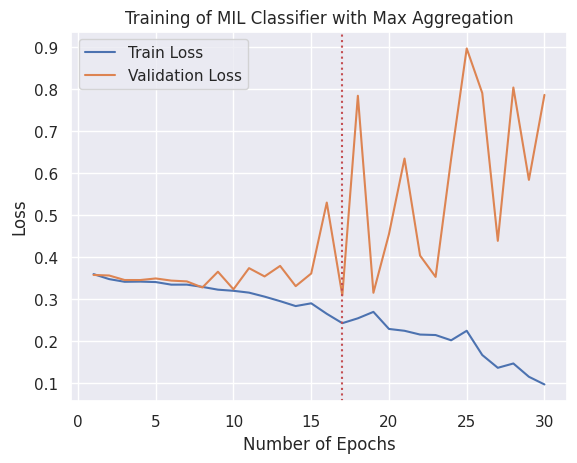

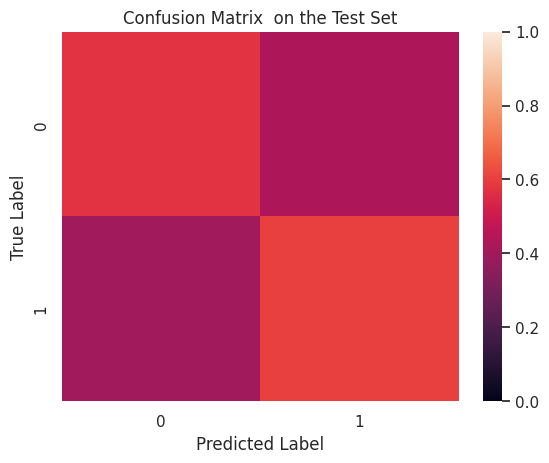

In [21]:
run_params = {}
if use_sparse_data:
    run_params = {
        "n_hidden": 3,
        "hidden_size": 10,
        "lr": 10**-2,
        "decay": 10**-2,
        "encoding_size": 10,
        "seed": 37,
    }
else:
    run_params = {
    "n_hidden": 1,
    "hidden_size": 30,
    "lr": 10**-2,
    "decay": 10**-1.7005985187830885,
    "seed": 27,
    "encoding_size": 30,
    }

set_seed(run_params["seed"])
encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"], hidden_size=run_params["hidden_size"], output_size=run_params["encoding_size"], input_size=INPUT_SIZE
)
aggregator = MaxAggergation(post_process=True, encoding_size=run_params["encoding_size"])

run_evaluation(encoder, aggregator, run_params["lr"], run_params["decay"], plot_title="Training of MIL Classifier with Max Aggregation", path_prefix=str(PROJECT_ROOT / "data/torch_playground_max_aggregation_models/epoch_"))

## Attention Aggregation

Epoch 1/30, Train Loss: 0.3589, Validation Loss: 0.3449
Epoch 2/30, Train Loss: 0.3436, Validation Loss: 0.3493
Epoch 3/30, Train Loss: 0.3354, Validation Loss: 0.3510
Epoch 4/30, Train Loss: 0.3322, Validation Loss: 0.3553
Epoch 5/30, Train Loss: 0.3277, Validation Loss: 0.3506
Epoch 6/30, Train Loss: 0.3271, Validation Loss: 0.3436
Epoch 7/30, Train Loss: 0.3237, Validation Loss: 0.3557
Epoch 8/30, Train Loss: 0.3184, Validation Loss: 0.3437
Epoch 9/30, Train Loss: 0.3105, Validation Loss: 0.3487
Epoch 10/30, Train Loss: 0.3044, Validation Loss: 0.3471
Epoch 11/30, Train Loss: 0.3004, Validation Loss: 0.3466
Epoch 12/30, Train Loss: 0.2923, Validation Loss: 0.3477
Epoch 13/30, Train Loss: 0.2924, Validation Loss: 0.3453
Epoch 14/30, Train Loss: 0.2775, Validation Loss: 0.3614
Epoch 15/30, Train Loss: 0.2776, Validation Loss: 0.3740
Epoch 16/30, Train Loss: 0.2573, Validation Loss: 0.3552
Epoch 17/30, Train Loss: 0.2507, Validation Loss: 0.3842
Epoch 18/30, Train Loss: 0.2425, Validat

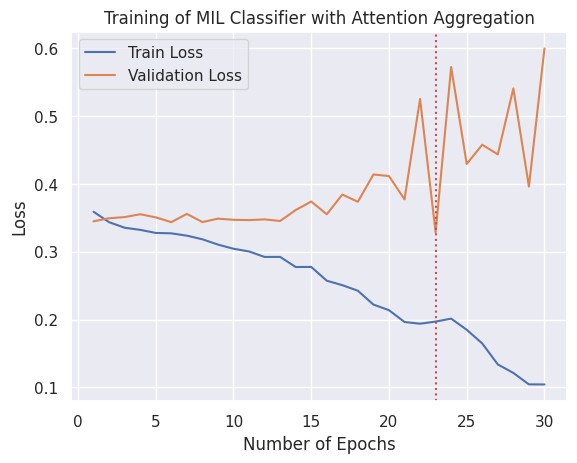

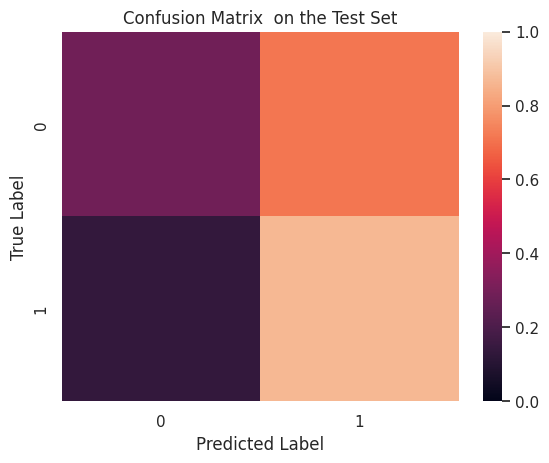

In [22]:
run_params={}

if use_sparse_data:
    run_params={
        "encoding_size": 10,
        "attention_hidden_size": 10,
        "hidden_size": 10,
        "lr": 10**-3,
        "decay": 10**-2,
        "n_hidden": 3,
        "seed": 2023,
    }
      
    
else:
    run_params={
        "encoding_size": 40,
        "attention_hidden_size": 10,
        "hidden_size": 40,
        "lr": 10**-2,
        "decay": 10**-2,
        "n_hidden": 3,
        "seed": 42,
    }

set_seed(run_params["seed"])

encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"], hidden_size=run_params["hidden_size"], output_size=run_params["encoding_size"], input_size=INPUT_SIZE
)
aggregator = AttentionAggregation(encoding_size=run_params["encoding_size"], attention_hidden_size=run_params["attention_hidden_size"])
run_evaluation(encoder, aggregator, run_params["lr"], run_params["decay"], plot_title="Training of MIL Classifier with Attention Aggregation", path_prefix=str(PROJECT_ROOT / "data/attention_aggregation_models/epoch_"))

## Gated Attention Aggregation

Epoch 1/30, Train Loss: 0.5494, Validation Loss: 0.3392
Epoch 2/30, Train Loss: 0.3755, Validation Loss: 0.5595
Epoch 3/30, Train Loss: 0.4028, Validation Loss: 0.3450
Epoch 4/30, Train Loss: 0.3600, Validation Loss: 0.3457
Epoch 5/30, Train Loss: 0.3272, Validation Loss: 0.3313
Epoch 6/30, Train Loss: 0.3131, Validation Loss: 0.3014
Epoch 7/30, Train Loss: 0.3179, Validation Loss: 0.2962
Epoch 8/30, Train Loss: 0.2912, Validation Loss: 0.3573
Epoch 9/30, Train Loss: 0.2814, Validation Loss: 0.3012
Epoch 10/30, Train Loss: 0.2729, Validation Loss: 0.4692
Epoch 11/30, Train Loss: 0.2716, Validation Loss: 0.3154
Epoch 12/30, Train Loss: 0.2940, Validation Loss: 0.4176
Epoch 13/30, Train Loss: 0.2151, Validation Loss: 0.3625
Epoch 14/30, Train Loss: 0.2162, Validation Loss: 0.3914
Epoch 15/30, Train Loss: 0.1761, Validation Loss: 0.9213
Epoch 16/30, Train Loss: 0.3267, Validation Loss: 0.3921
Epoch 17/30, Train Loss: 0.2618, Validation Loss: 0.5785
Epoch 18/30, Train Loss: 0.1993, Validat

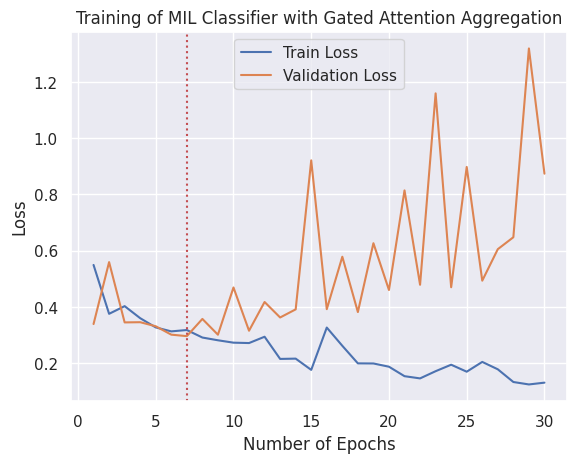

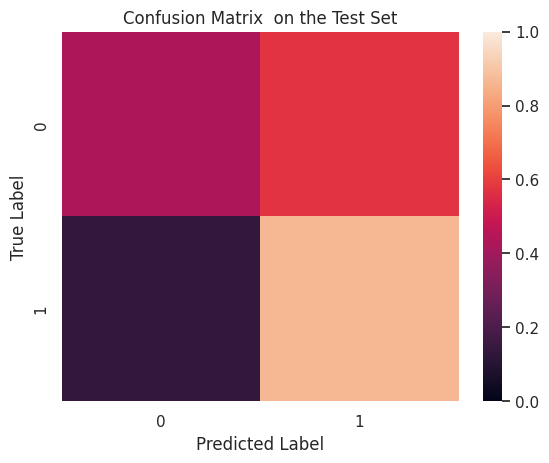

In [23]:
run_params = {}

if use_sparse_data:
    run_params = {
        "encoding_size": 10,
        "attention_hidden_size": 10,
        "hidden_size": 20,
        "lr": 10**-2,
        "decay": 10**-2,
        "n_hidden": 3,
        "seed": 0,
    }
else:
    run_params = {
        "encoding_size": 4,
        "attention_hidden_size": 42,
        "hidden_size": 43,
        "lr": 10**-2,
        "decay": 10**-2,
        "n_hidden": 2,
        "seed": 0,
    }

set_seed(run_params["seed"])
encoder = MLP_encoder(
    n_hidden=run_params["n_hidden"], 
    hidden_size=run_params["hidden_size"], 
    output_size=run_params["encoding_size"], 
    input_size=INPUT_SIZE
)
aggregator = GatedAttentionAggregation(
    encoding_size=run_params["encoding_size"], 
    attention_hidden_size=run_params["attention_hidden_size"]
)

run_evaluation(
    encoder, 
    aggregator, 
    run_params["lr"], 
    run_params["decay"], 
    plot_title="Training of MIL Classifier with Gated Attention Aggregation",
    path_prefix=str(PROJECT_ROOT / "data/gated_attention_aggregation_models/epoch_")
)